# **Activation Functions in Neural Networks** - ReLU vs Sigmoid vs Tanh
## Dataset: MNIST


In [1]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report

sns.set_palette("colorblind")
plt.rcParams["figure.figsize"] = (8,6)

print("Libraries imported successfully")

Libraries imported successfully


### Load Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training shape: (60000, 28, 28)
Testing shape: (10000, 28, 28)


### Normalize Data

In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print("Normalization completed")

Normalization completed


### Class Labels

In [4]:
class_names = [str(i) for i in range(10)]

print(class_names)

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


### Visualize Dataset

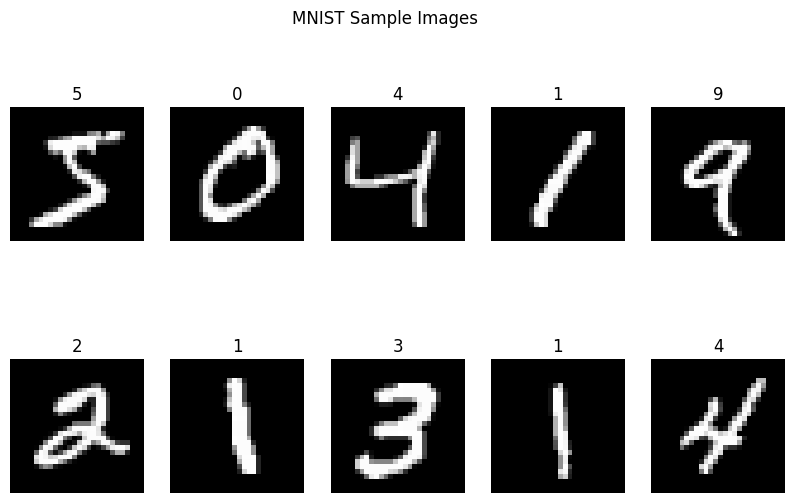

In [5]:
plt.figure(figsize=(10,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("MNIST Sample Images")

plt.savefig("figure1_mnist_samples.png", dpi=300, bbox_inches="tight")

plt.show()

### Model Building Function

In [6]:
def build_model(activation_function):

    model = Sequential()

    model.add(Flatten(input_shape=(28,28)))

    model.add(Dense(128, activation=activation_function))

    model.add(Dense(128, activation=activation_function))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer=Adam(),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

### Train Models

In [7]:
activations = ["relu","sigmoid","tanh"]

history_results = {}
accuracy_results = {}

for act in activations:

    print(f"\nTraining model with {act} activation")

    model = build_model(act)

    history = model.fit(
        X_train,
        y_train,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    history_results[act] = history

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    accuracy_results[act] = test_acc

    print("Test accuracy:", test_acc)


Training model with relu activation


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8977 - loss: 0.3579 - val_accuracy: 0.9522 - val_loss: 0.1689
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9578 - loss: 0.1417 - val_accuracy: 0.9644 - val_loss: 0.1190
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9716 - loss: 0.0951 - val_accuracy: 0.9696 - val_loss: 0.1003
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9788 - loss: 0.0724 - val_accuracy: 0.9702 - val_loss: 0.0925
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9833 - loss: 0.0559 - val_accuracy: 0.9721 - val_loss: 0.0916
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9866 - loss: 0.0437 - val_accuracy: 0.9737 - val_loss: 0.0869
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9901 - loss: 0.0335 - val_accuracy: 0.9722 - val_loss: 0.0967
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9916 - loss: 0.0267 - val_accuracy: 0

### Training Accuracy Plot

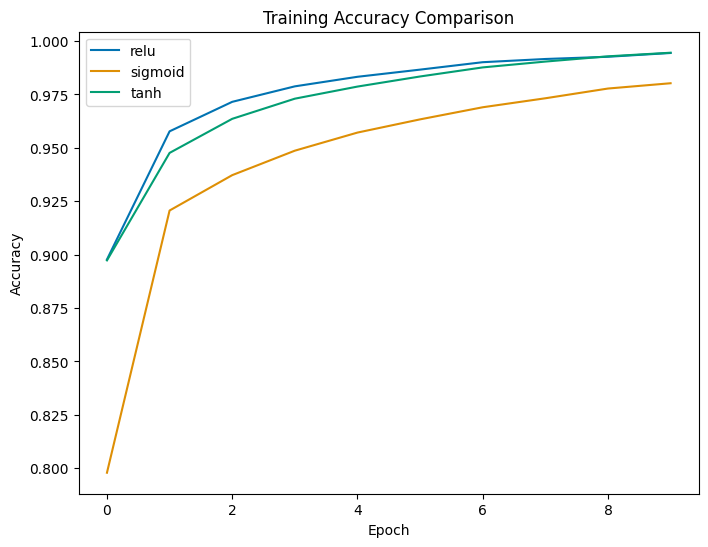

In [8]:
plt.figure()

for act in activations:
    plt.plot(history_results[act].history["accuracy"], label=act)

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("figure2_training_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

### Validation Accuracy Plot

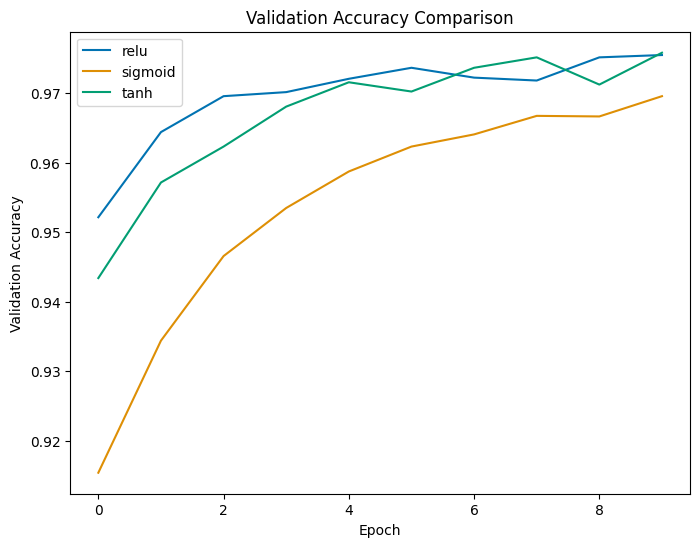

In [9]:
plt.figure()

for act in activations:
    plt.plot(history_results[act].history["val_accuracy"], label=act)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("figure3_validation_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

### Training Loss Plot

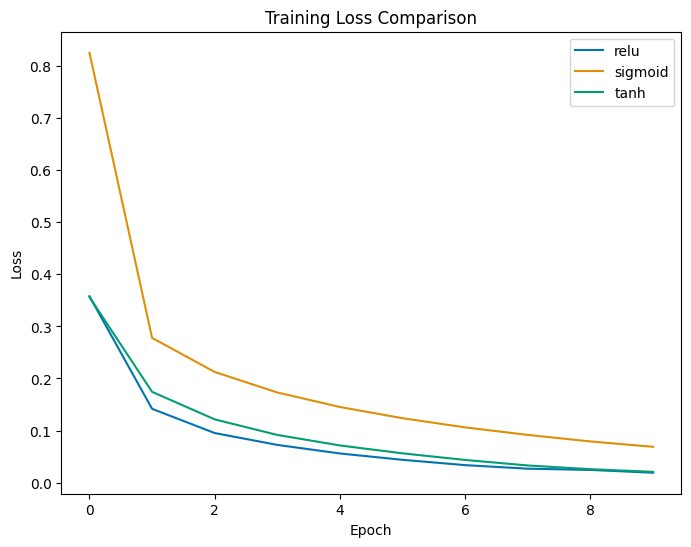

In [10]:
plt.figure()

for act in activations:
    plt.plot(history_results[act].history["loss"], label=act)

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("figure4_training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

### Accuracy Comparison

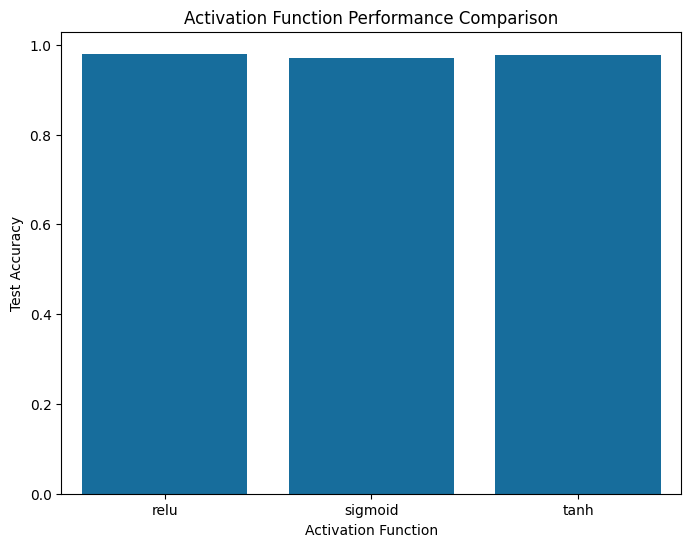

In [11]:
acts = list(accuracy_results.keys())
accs = list(accuracy_results.values())

plt.figure()

sns.barplot(x=acts, y=accs)

plt.xlabel("Activation Function")
plt.ylabel("Test Accuracy")
plt.title("Activation Function Performance Comparison")

plt.savefig("figure5_activation_accuracy.png", dpi=300, bbox_inches="tight")

plt.show()

### Train Best Model

In [12]:
best_activation = max(accuracy_results, key=accuracy_results.get)

print("Best activation:", best_activation)

best_model = build_model(best_activation)

best_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Best activation: relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9019 - loss: 0.3512 - val_accuracy: 0.9546 - val_loss: 0.1638
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9584 - loss: 0.1371 - val_accuracy: 0.9651 - val_loss: 0.1168
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9720 - loss: 0.0938 - val_accuracy: 0.9670 - val_loss: 0.1067
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9780 - loss: 0.0706 - val_accuracy: 0.9691 - val_loss: 0.1000
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9834 - loss: 0.0563 - val_accuracy: 0.9710 - val_loss: 0.0988
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9868 - loss: 0.0427 - val_accuracy: 0.9718 - val_loss: 0.0985
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9897 - loss: 0.0344 - val_accuracy: 0.9735 - val_loss: 0.0913
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9914 - loss: 0.0281 - val_accuracy: 0

### Predictions

In [13]:
y_pred_probs = best_model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


### Classification Report

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.97      0.98      1032
           3       0.96      0.98      0.97      1010
           4       0.98      0.97      0.97       982
           5       0.97      0.98      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.99      0.93      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



### Confusion Matrix

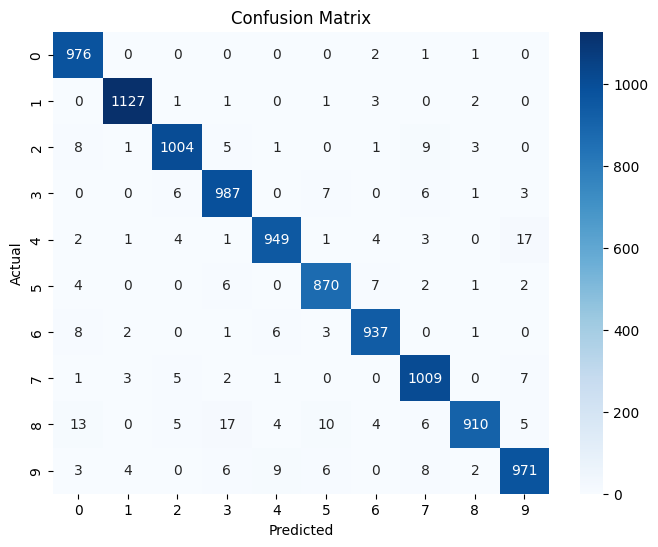

In [15]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.savefig("figure6_confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Prediction Examples

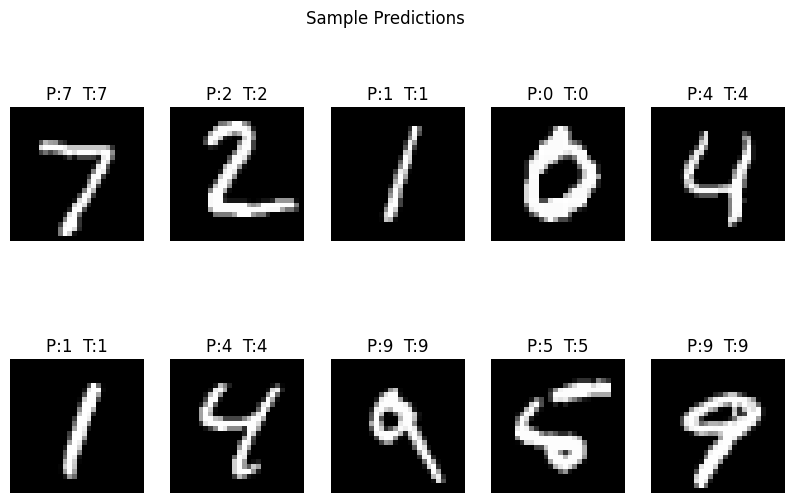

In [16]:
plt.figure(figsize=(10,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap="gray")

    plt.title(f"P:{y_pred[i]}  T:{y_test[i]}")

    plt.axis("off")

plt.suptitle("Sample Predictions")

plt.savefig("figure7_predictions.png", dpi=300, bbox_inches="tight")

plt.show()